<a href="https://colab.research.google.com/github/Zaidan1140/2318078MuhammadZaidanKlasifikasiCitraBungaMetodeKNN/blob/main/2318078MuhammadZaidanKlasifikasiCitraBungaMetodeKNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Import Library

In [1]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 2. Hubungkan Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 3. Set Dataset

In [3]:
DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/Dataset_bunga"
categories = ["bunga_tulip", "bunga_matahari"]
IMG_SIZE = 100

# 4. Cek Jumlah Data

In [4]:
for category in categories:
    path = os.path.join(DATASET_PATH, category)
    print(category, ":", len(os.listdir(path)))

bunga_tulip : 100
bunga_matahari : 100


# 5. Visualisasi Jumlah Dataset

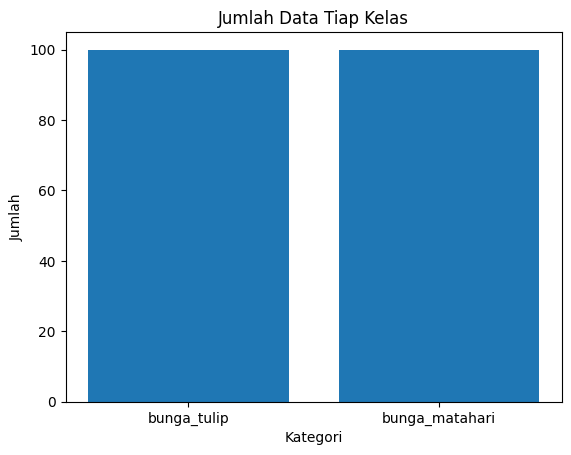

In [5]:
jumlah_data = []

for category in categories:
    path = os.path.join(DATASET_PATH, category)
    jumlah_data.append(len(os.listdir(path)))

plt.figure()
plt.bar(categories, jumlah_data)
plt.title("Jumlah Data Tiap Kelas")
plt.xlabel("Kategori")
plt.ylabel("Jumlah")
plt.show()

# 6. Tampilkan Contoh Gambar

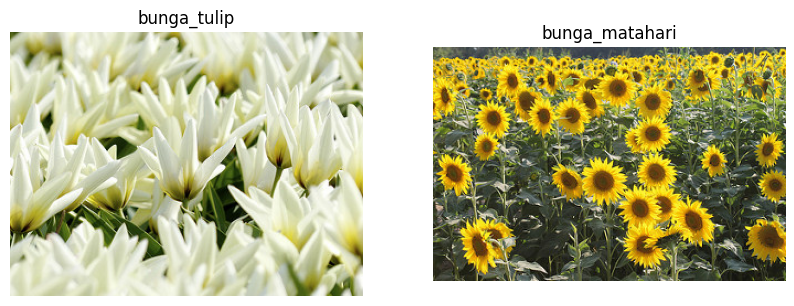

In [7]:
import random

plt.figure(figsize=(10,5))

for i, category in enumerate(categories):
    path = os.path.join(DATASET_PATH, category)
    img_name = random.choice(os.listdir(path))
    img_path = os.path.join(path, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 2, i+1)
    plt.imshow(img)
    plt.title(category)
    plt.axis("off")

plt.show()

# 7. Load & Preprocessing

In [8]:
data = []
labels = []

for category in categories:
    path = os.path.join(DATASET_PATH, category)
    label = categories.index(category)

    for img_name in os.listdir(path):

        # filter file gambar saja
        if not (img_name.endswith(".jpg") or img_name.endswith(".png")):
            continue

        try:
            img_path = os.path.join(path, img_name)
            image = cv2.imread(img_path)

            if image is None:
                continue

            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
            image = image.flatten()

            data.append(image)
            labels.append(label)

        except Exception as e:
            print("Error:", e)

data = np.array(data) / 255.0
labels = np.array(labels)

print("Total data:", len(data))

Total data: 200


# 8. Split Data

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42
)

print("Train:", len(X_train))
print("Test:", len(X_test))

Train: 160
Test: 40


# 9. Training KNN

In [10]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

# 10. Evaluasi Model

In [11]:
y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Akurasi:", accuracy)

Akurasi: 0.625


Classification Report

In [12]:
print(classification_report(y_test, y_pred, target_names=categories))

                precision    recall  f1-score   support

   bunga_tulip       1.00      0.29      0.44        21
bunga_matahari       0.56      1.00      0.72        19

      accuracy                           0.62        40
     macro avg       0.78      0.64      0.58        40
  weighted avg       0.79      0.62      0.57        40



Confusion Matrix

In [13]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 6 15]
 [ 0 19]]


# 11. Grafik Akurasi

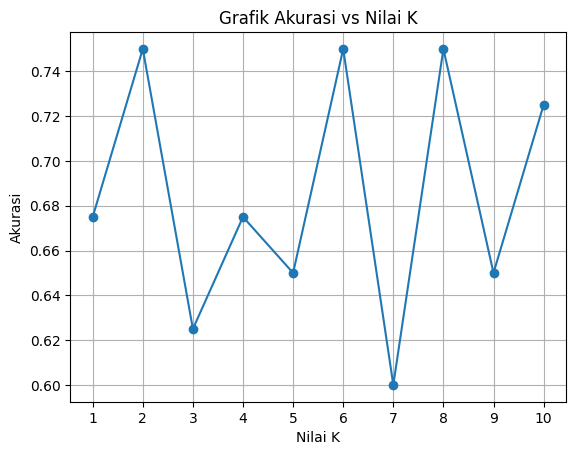

In [14]:
k_values = range(1, 11)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    y_pred_k = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred_k)
    accuracies.append(acc)

plt.figure()
plt.plot(k_values, accuracies, marker='o')
plt.title("Grafik Akurasi vs Nilai K")
plt.xlabel("Nilai K")
plt.ylabel("Akurasi")
plt.xticks(k_values)
plt.grid()

plt.show()

# 12. Prediksi Gambar Baru

In [25]:
def predict_image(img_path):
    img = cv2.imread(img_path)

    if img is None:
        return "Gambar tidak terbaca"

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.flatten().reshape(1, -1)

    prediction = knn.predict(img)
    return categories[prediction[0]]

Hasil Prediksi: bunga_tulip


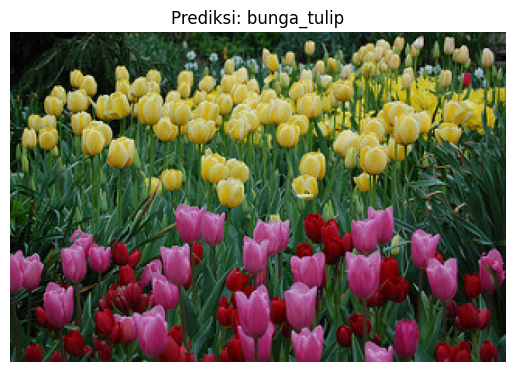

In [30]:
import random

# ambil gambar random dari dataset
path = os.path.join(DATASET_PATH, "bunga_tulip")
img_name = random.choice(os.listdir(path))
test_image = os.path.join(path, img_name)

# prediksi
hasil = predict_image(test_image)
print("Hasil Prediksi:", hasil)

# tampilkan
img = cv2.imread(test_image)

if img is not None:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.title("Prediksi: " + hasil)
    plt.axis("off")
    plt.show()
else:
    print("Gagal tampil gambar")

# 13. Tampilkan Hasil Prediksi

In [33]:
# pastikan variabel ada
test_image = "/content/drive/MyDrive/test_bunga.jpg"

img = cv2.imread(test_image)

if img is None:
    print("Gambar tidak ditemukan / path salah")
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.title("Prediksi: " + hasil)
    plt.axis("off")
    plt.show()

Gambar tidak ditemukan / path salah


# Tampilkan Confusion Matrix

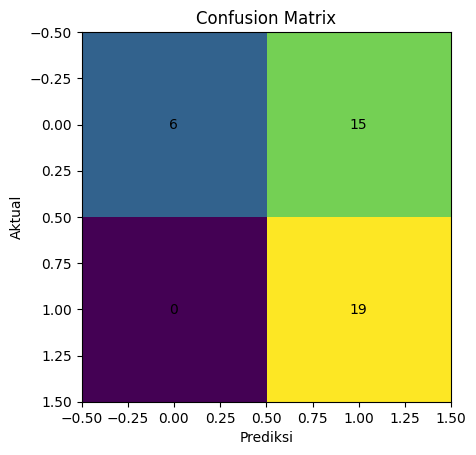

In [31]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.show()

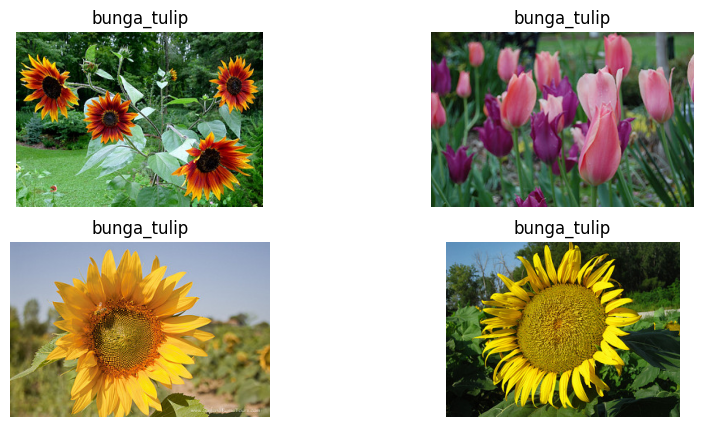

In [32]:
import random

plt.figure(figsize=(10,5))

for i in range(4):
    category = random.choice(categories)
    path = os.path.join(DATASET_PATH, category)
    img_name = random.choice(os.listdir(path))
    img_path = os.path.join(path, img_name)

    hasil = predict_image(img_path)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(hasil)
    plt.axis("off")

plt.show()

In [35]:
import os
import pandas as pd

save_path = "/content/drive/MyDrive/Colab Notebooks/Hasil_KNN_Bunga"
os.makedirs(save_path, exist_ok=True)

# hanya simpan yang penting saja
df_simple = pd.DataFrame({
    "Label_Asli": [categories[label] for label in y_test],
    "Hasil_Prediksi": [categories[label] for label in y_pred],
    "Status": y_test == y_pred
})

output_path = os.path.join(save_path, "hasil_klasifikasi_bunga.xlsx")

df_simple.to_excel(output_path, index=False)

print("✅ File berhasil disimpan:", output_path)

✅ File berhasil disimpan: /content/drive/MyDrive/Colab Notebooks/Hasil_KNN_Bunga/hasil_klasifikasi_bunga.xlsx
